# 2 — Forecasting and results

The question this notebook answers is a specific one:

> Standing at the end of the available history, how accurately can the next twelve
> weeks of demand be predicted for every store and department — and is that better
> than repeating what happened last year?

Twelve weeks is not arbitrary. It is roughly the lead time a planner is working
against: the order placed today covers a quarter ahead. That single choice constrains
everything else in this notebook.

In [1]:
import sys
from pathlib import Path

# Notebooks live one level below the project root; the shared code lives in src/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src import config, data, evaluate, features, models, plots

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

In [2]:
panel = data.build_panel()
print(f"{len(panel):,} store-department weeks")

449,237 store-department weeks


## The rule that governs every feature

A forecast is only worth anything if it could have been made at the time. With a
twelve-week horizon, the most recent sales figure available when the order is placed
is twelve weeks old.

So there is no feature here built on last week's sales. There cannot be — the planner
would not have had it. This is the single most common way a forecasting demonstration
flatters itself, and it is worth being blunt about, because a model given last week's
sales will post excellent numbers that collapse the moment it is used for real.

What the model does get:

- **Sales history no fresher than twelve weeks** — the value at twelve, thirteen,
  fourteen and fifteen weeks back, plus the same week one and two years ago.
- **Rolling averages and volatility**, computed on that already-delayed history.
- **A seasonal index per series** — this department's share of its own normal
  turnover in this calendar week, learned from previous years only.
- **Calendar and holiday markers**, including the week *before* each major holiday,
  since stock has to arrive before the peak, not during it.
- **Store attributes and external signals** — format, size, promotions, fuel price,
  local unemployment, temperature.

In [3]:
frame = features.build_feature_frame(panel, config.HOLDOUT_WEEKS)
feature_cols = features.feature_columns(frame)

print(f"{len(feature_cols)} features")
[c for c in feature_cols if c.startswith("SalesLag")]

47 features


['SalesLag12',
 'SalesLag13',
 'SalesLag14',
 'SalesLag15',
 'SalesLag52',
 'SalesLag104']

Note what is absent from that list: there is no `SalesLag1`. The shortest lag equals
the forecast horizon.

## Splitting by time, never at random

The history is cut into three consecutive blocks. A random split would let the model
train on weeks that come *after* the weeks it is scored on, which produces an
impressive and completely meaningless number.

The middle block exists so that the model's stopping point is chosen without ever
looking at the final block. Tuning against the hold-out would quietly turn the
reported accuracy into an in-sample figure.

In [4]:
split = models.make_time_split(frame)

print(f"train      : up to {split.validation_start.date()}")
print(f"validation : {split.validation_start.date()} to {split.holdout_start.date()}")
print(f"hold-out   : {split.holdout_start.date()} onwards")
split.describe()

train      : up to 2012-05-18
validation : 2012-05-18 to 2012-08-10
hold-out   : 2012-08-10 onwards


,Block,Rows
0,Train,350595
1,Validation,35412
2,Hold-out,35563


## The benchmark: what a planner does today

"Order what we sold in the same week last year." Where no such figure exists, fall
back on the recent average. This is not a strawman — in strongly seasonal categories
it is a hard benchmark to beat, and beating it by a little is a more honest result
than beating a deliberately weak one by a lot.

In [5]:
frame["Baseline_Forecast"] = models.seasonal_naive_forecast(frame, config.HOLDOUT_WEEKS)

## One model for all 3,331 series

Fitting a separate model per store-department would mean thousands of models to
retrain, monitor and explain, each seeing only its own thin slice of history.

A single model with store and department as inputs learns patterns that transfer —
a Christmas shape observed in one store informs the same department elsewhere — and
is what an actual deployment looks like.

The model optimises absolute error rather than squared error. Squared error lets the
handful of enormous weeks dominate the fit, at the expense of the thousands of
ordinary weeks that make up most of the ordering decisions.

In [6]:
model, feature_cols = models.fit_model(frame, split)
frame["XGBoost_Forecast"] = models.predict(model, frame, feature_cols)

print(f"trees used: {model.best_iteration + 1} of {model.n_estimators}")

trees used: 1200 of 1200


## Results

`WMAPE` — total absolute error divided by total sales volume — is the headline figure
rather than plain MAPE. Plain MAPE divides by each week's actual value, and this data
contains zero-sales and negative-sales weeks that make that division explode or become
undefined. WMAPE answers the question a planner actually asks: *across everything I
ordered, what share of the volume did I get wrong?*

MAPE is reported alongside it, restricted to weeks with meaningful turnover, because
clients expect to see it.

In [7]:
holdout = frame.loc[split.holdout]
forecast_cols = {"Seasonal naive": "Baseline_Forecast", "XGBoost": "XGBoost_Forecast"}

summary = evaluate.score_models(holdout, "Weekly_Sales", forecast_cols)
summary.style.format({"WMAPE": "{:.2%}", "MAPE": "{:.2%}", "Bias": "{:+.2%}",
                      "RMSE": "{:,.0f}", "MAE": "{:,.0f}"})

,Model,Weeks,WMAPE,MAPE,RMSE,MAE,Bias
0,Seasonal naive,35563,10.79%,20.02%,"3,627","1,682",-1.69%
1,XGBoost,35563,8.85%,19.02%,"2,872","1,379",+0.42%


In [8]:
indexed = summary.set_index("Model")

for metric in ["WMAPE", "RMSE", "MAE"]:
    gain = evaluate.improvement(indexed.loc["Seasonal naive", metric],
                                indexed.loc["XGBoost", metric])
    print(f"{metric:>6} improvement over the baseline: {gain:6.1%}")

 WMAPE improvement over the baseline:  18.0%
  RMSE improvement over the baseline:  20.8%
   MAE improvement over the baseline:  18.0%


`Bias` is worth reading separately from the error size. It is the average signed
error as a share of volume — whether the forecast systematically runs high or low.
The distinction is commercial, not statistical: a forecast that is noisy but unbiased
costs safety stock, while one that is consistently low causes stockouts that no
safety-stock policy will fix.

## Does the result hold up, or is it an average hiding a weak spot?

An overall number is easy to produce and easy to distrust. Two breakdowns:

In [9]:
by_type = evaluate.score_by_segment(holdout.assign(StoreType=holdout["Type"].astype(str)),
                                    "StoreType", "Weekly_Sales", forecast_cols)
by_type.style.format({"Seasonal naive_WMAPE": "{:.2%}", "XGBoost_WMAPE": "{:.2%}",
                      "ActualVolume": "{:,.0f}", "Seasonal naive_RMSE": "{:,.0f}",
                      "XGBoost_RMSE": "{:,.0f}"})

,StoreType,Weeks,ActualVolume,Seasonal naive_WMAPE,Seasonal naive_RMSE,XGBoost_WMAPE,XGBoost_RMSE
0,A,18134,"356,740,389",10.29%,"4,199",8.45%,"3,389"
1,B,13737,"162,769,384",12.33%,"3,041",10.16%,"2,355"
2,C,3692,"34,862,318",8.70%,"2,388",6.74%,"1,536"


In [10]:
by_week = evaluate.score_by_segment(holdout, "Date", "Weekly_Sales", forecast_cols)
by_week[["Date", "Weeks", "Seasonal naive_WMAPE", "XGBoost_WMAPE"]].sort_values("Date")

,Date,Weeks,Seasonal naive_WMAPE,XGBoost_WMAPE
0,2012-08-10,2957,0.101311,0.079539
1,2012-08-17,2955,0.103756,0.082823
2,2012-08-24,2960,0.121020,0.098656
3,2012-08-31,2962,0.123566,0.106613
4,2012-09-07,2966,0.109460,0.085079
5,2012-09-14,2967,0.091676,0.079712
6,2012-09-21,2959,0.108012,0.084074
7,2012-09-28,2962,0.107193,0.092332
8,2012-10-05,2976,0.107043,0.088787
9,2012-10-12,2990,0.105587,0.089512


The model is ahead in every store format and in every single week of the hold-out.
A result that only appeared on average, or only in some weeks, would be a sign of
luck rather than signal.

## What the model relies on

findfont: Failed to find font weight 600, now using 700.


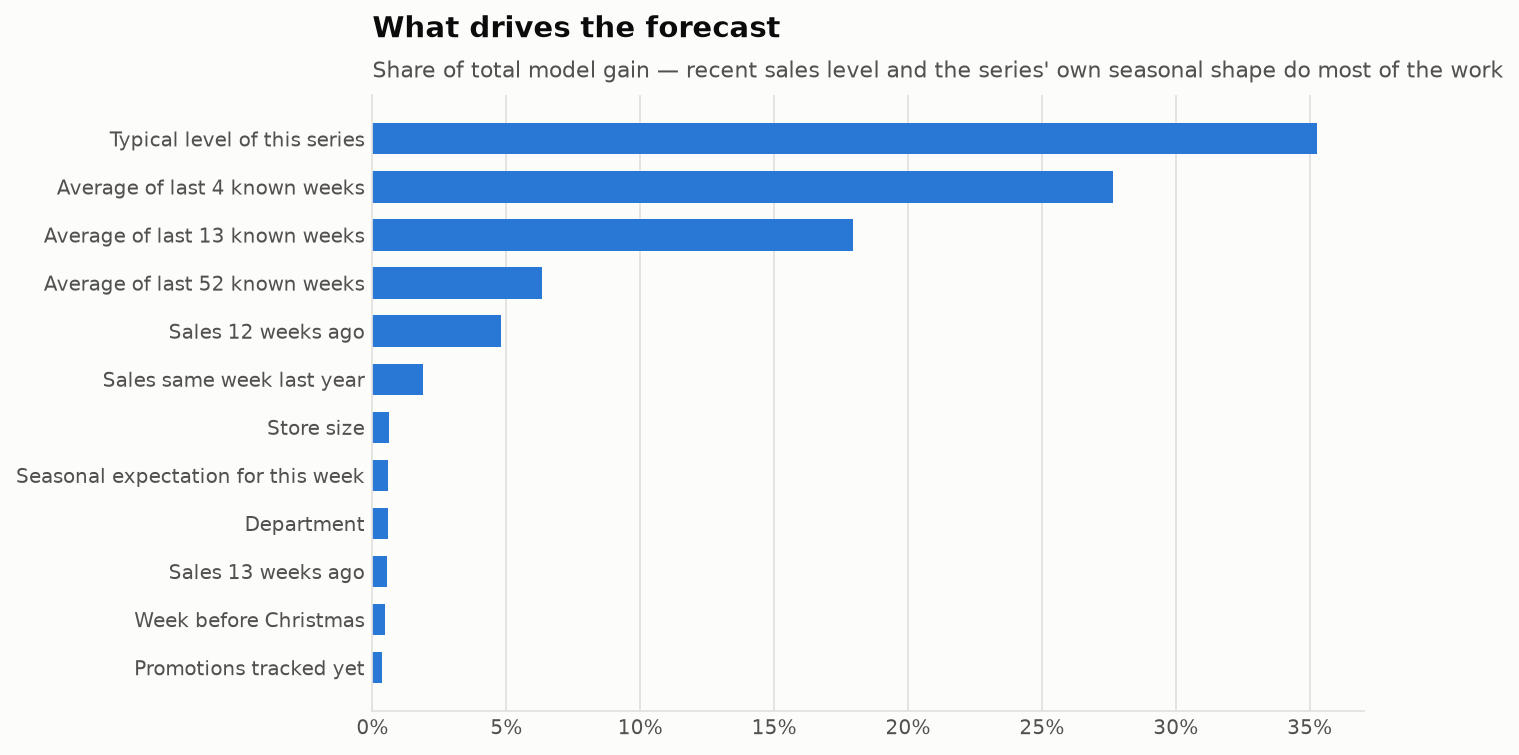

In [11]:
importance = models.feature_importance(model, feature_cols)
plots.plot_feature_importance(importance)

from IPython.display import Image, display

display(Image(str(config.FIGURES_DIR / "06_feature_importance.png")))

No surprises here, which is itself reassuring. The model leans on each series' own
recent level and its seasonal shape — the same two things an experienced planner
uses. It is doing that consistently across 3,331 series and weighing the two against
each other per series, which is the part a person cannot do by hand every week.

The external signals — fuel price, unemployment, temperature — contribute very
little. Worth knowing before promising a client that macroeconomic data will improve
their forecast.

## A single series, in detail

findfont: Failed to find font weight 600, now using 700.


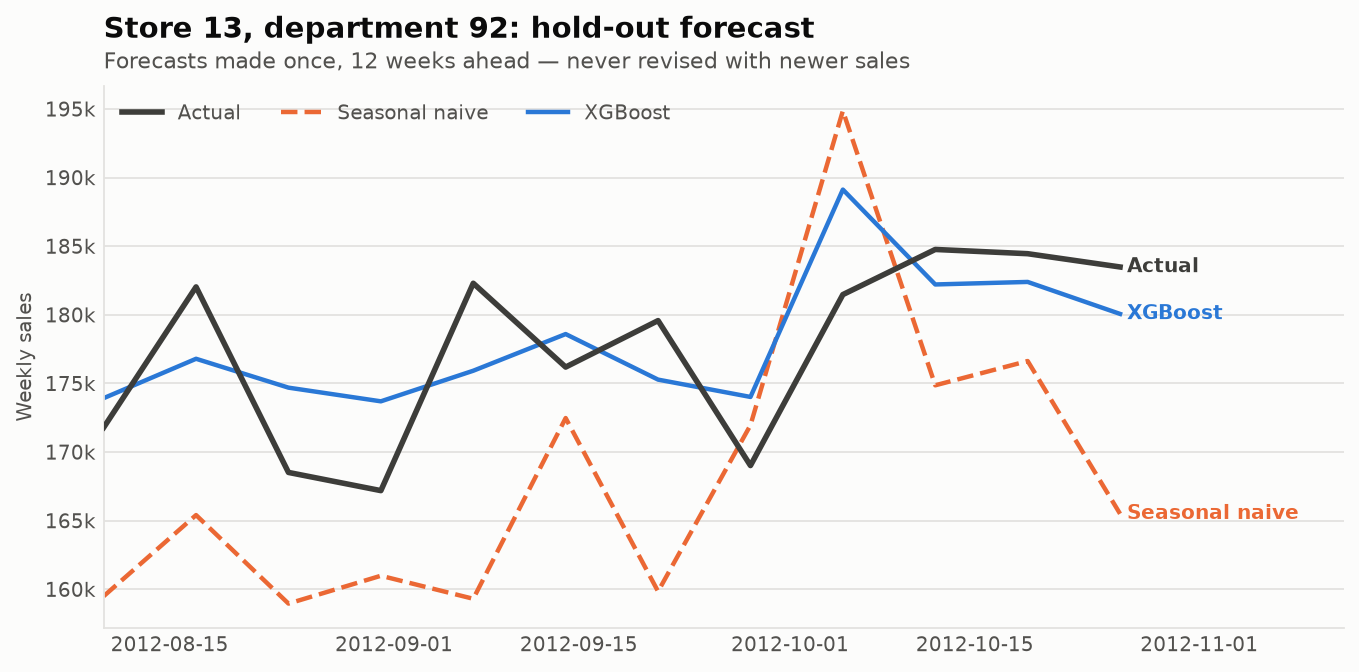

In [12]:
results = pd.read_csv(config.OUTPUTS_DIR / "forecast_vs_actual.csv", parse_dates=["Date"])

busiest = results.groupby(["Store", "Dept"])["Actual"].sum().idxmax()
plots.plot_forecast_vs_actual(results, int(busiest[0]), int(busiest[1]))

display(Image(str(config.FIGURES_DIR / "04_forecast_vs_actual.png")))

## Output for reporting

The hold-out predictions are written to `outputs/forecast_vs_actual.csv` as a flat
table — one row per store, department and week, with actual, both forecasts, and the
error of each. It imports into Power BI or Excel directly and pivots by store,
department, week or store format without further shaping.

The full pipeline, from raw files to these extracts, runs with:

```
python -m src.run_pipeline
```

In [13]:
results.head()

,Store,Dept,StoreType,StoreSize,Date,IsHolidayWeek,Actual,Baseline_Forecast,XGBoost_Forecast,Baseline_Error,Baseline_AbsError,XGBoost_Error,XGBoost_AbsError
0,1,1,A,151315,2012-08-10,False,16119.92,14539.79,15509.310,-1580.13,1580.13,-610.610430,610.610430
1,1,1,A,151315,2012-08-17,False,17330.70,14689.24,15425.136,-2641.46,2641.46,-1905.564258,1905.564258
2,1,1,A,151315,2012-08-24,False,16286.40,14537.37,15907.995,-1749.03,1749.03,-378.404883,378.404883
3,1,1,A,151315,2012-08-31,False,16680.24,15277.27,15884.323,-1402.97,1402.97,-795.916758,795.916758
4,1,1,A,151315,2012-09-07,True,18322.37,17746.68,18970.398,-575.69,575.69,648.028438,648.028438


## Honest limitations

- **Two and a half years of history.** Two complete annual cycles is the bare minimum
  for learning a yearly pattern. A third year would likely help more than any
  modelling change.
- **One hold-out window.** The result covers a twelve-week period in late summer,
  which contains no major holiday. Accuracy through November and December — the weeks
  that matter most — is not measured here and should not be assumed equal.
- **Departments, not articles.** Real ordering happens at article level, where series
  are thinner and noisier. The method carries over; the accuracy figures would not.
- **No stock or capacity data.** This forecasts demand. Turning that into order
  proposals needs lead times, minimum order quantities and shelf constraints.